# Unit 3 Assessment - Empirical Models

## Instructions

In this assessment, you are going to develop an emperical model by fitting a curve to data, and you will use your model to make predictions.

Scores are determined by:

- Successfully starting the C Level = 50 pts
- Perfectly completing the C Level = 75 pts
- Perfectly completing the B and C Levels = 85 pts
- Perfectly completing the A, B, and C Levels = 100 pts

You may use your Colab notebooks, our textbook, my notebook solutions, and any links to web sites I provide. (You may not use any other person or web site or book or resource, in general.) 

You may ask me for help **once**; however, you may ask for clarification as often as needed.

Add additional cells for both code and markdown as needed. **Write answers to questions in narrative form in markdown.** You may print values you need in your code, and then use these values in a written response.

**All graphs should have correct titles and axis labels (with units).**

**All number should have proper units**

### **Using resources**

You may use your Colab notebooks from class, any other notebook or reading I have given you, and any links to web sites I have provided. Basically, if it is linked on Blackboard then you can use it.

You may not use any other person, website, book, or resource. This includes the AI features in Google Colab or any other generative AI tool (ChatGPT, etc.) You are responsible for using only approved resources. If you're unsure whether something is allowed, please ask me before using it.

You can disable the Gemini AI assistance by going to settings and unchecking `Show AI-powered inline completions` and `Consented to use generative AI features` and checking `Hide generative AI features.` as seen below.

### **Citing Sources**

Citing sources isn't just about copying and pasting code—it's about giving credit whenever you use ideas, inspiration, or guidance from another source, even if you don't copy directly. Here's how to handle it:

- **When to Cite**:
  - If you refer to a **specific code example** from class materials, notebooks, or a reading.
    - Example: "I used the loop structure from the `02-01-random` notebook, exercise 1."
  - When you use an **idea** or approach that you didn't come up with on your own, even if you modify it.
    - Example: "The way I calculated the probability of finding the area of a circle was based on the pre-class notebook for Day 3."
  - **Even if you don't copy-paste** code, if something influenced your thinking or the way you structured your solution, it should be cited.
  
- **What doesn't need citation**:
  - Basic ideas that come entirely from your own brain.
  - Simple language constructs like loops, if-statements, or variables, unless they come directly from an example you're referencing.

- **Key points**
  - It's always better to cite than to leave something out. You won't lose points for over-citing and I will give you feedback on what citations are required or not.
  - Don't just cite when you copy code—cite when ideas or problem-solving approaches come from an outside source.

- **Examples of Correct Citations**:
  - **Copied/Modified Code**: "We used the code from the `randomwalk1D` function in the `02-03-random-walk` notebook to help structure our loop."
  - **Concept or Inspiration**: "We based our approach for determining the circle a dart landed in on the exmaple we did in class estimating $\pi$. "

## Grade

<font color="green"></font>

Level | Grade | Comment
--- | --- | ---
C (75 pts) | | 
B (10 pts) | | 
A (15 pts) | | 
Total | 


# Level C

## Exercise 0

1. Save a copy of this notebook to Google Drive in the folder you have shared with me. 

2. Add a text cell above and type your name as a level one heading in markdown. (A level one heading starts with # on its own line.)

3. Run the `import` statements below to add packages.

In [3]:
import numpy as np #used for arrays and numerical functions
import pandas as pd #used for reading a data file
import matplotlib.pyplot as plt #used for graphing
from io import StringIO #used to convert string to a dataframe
from scipy.optimize import curve_fit #used to find the fit parameters

## Exercise 1

As the temperature of a solution increases, the amount of solute that can be dissolved increases. This [data set](https://raw.githubusercontent.com/anthoak13/HNR-1303-F24/F25/unit-03/03-10-problem/solubility.txt) ([source](https://pubs.acs.org/doi/10.1021/je00045a020)) shows the amount of sodium chloride (measured in g) that can be dissolved in 100 g of a particular water-based solvent. Read the data and graph the amount of sodium chloride that can be dissolved as a function of temperature.

   Temp (C)  NaCl Solubility (g)
0      27.0                26.76
1      30.0                26.79
2      40.0                27.28
3      45.0                27.86
4      50.0                26.89


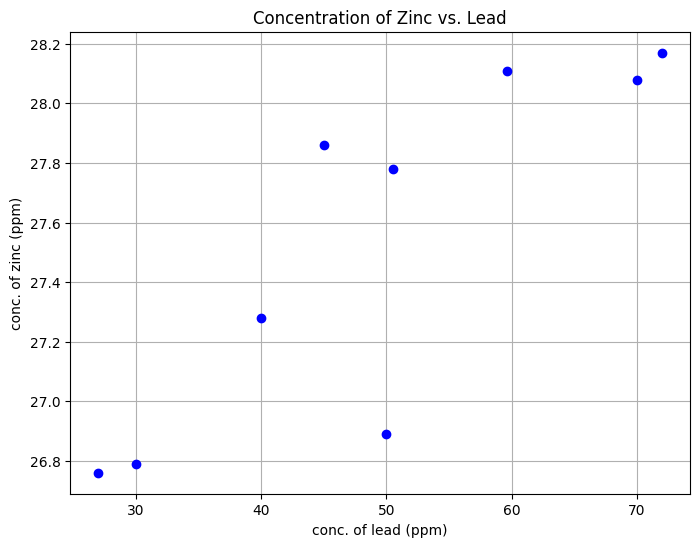

In [12]:
# convert data to dataframe
df = pd.read_csv("https://raw.githubusercontent.com/anthoak13/HNR-1303-F24/F25/unit-03/03-10-problem/solubility.txt", sep ="\t")
data = """Temp (C)	NaCl Solubility (g)
27.0	26.76  
30.0	26.79  
40.0	27.28  
45.0	27.86  
50.0	26.89  
50.5	27.78  
59.6	28.11 
70.0	28.08 
72.0	28.17 """
df = pd.read_csv(StringIO(data), sep ="\t")
print(df.head())

# define arrays for the data
xdata = df['Temp (C)']
ydata = df['NaCl Solubility (g)']


# plot data and the best-fit function on the same graph
fig = plt.figure(figsize=(8,6))
plt.title("Concentration of Zinc vs. Lead")
plt.xlabel('conc. of lead (ppm)')
plt.ylabel('conc. of zinc (ppm)')
plt.grid(which='both', axis='both')
plt.plot(xdata, ydata, 'bo') #plot data
plt.show()

## Exercise 2

Using the data from Exercise 1, perform a linear curve fit to model the relationship between temperature and NaCl solubility. Plot the best-fit line along with the original data on the same graph. Report the best-fit parameters for your model.

## Exercise 3

Using your curve-fit, predict the amount of NaCl that can be dissolved at 0, 45, 80, and 100 $\text{C}^\circ$.

## Exercise 4

Evaluate the predictions you made in Exercise 3. Which predictions do you believe are valid, and why? For predictions that seem less accurate or reasonable, explain why you think this is the case. 

# Level B

Two HPU alumni, Chris Schorn and Shane Wiess, tested a t-shirt launcher designed and constructed by alumnus Noah Novembre. Chris and Shane measured the exit speed of a t-shirt as a function of the air pressure in the barrel. This [file](https://raw.githubusercontent.com/anthoak13/HNR-1303-F24/F25/unit-03/03-10-problem//pressure-speed.txt) has their data.



## Exercise 1
Read the data and plot the exit speed of the t-shirt (when exiting the barrel) as a function of the air pressure in the barrel.

   P (psi)  v (m/s)
0       20     1.36
1       25     2.24
2       30     3.52
3       35     4.33
4       40     5.22


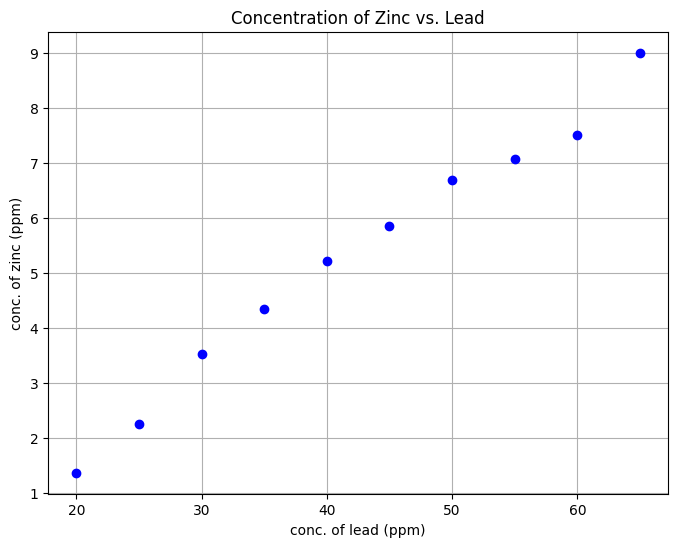

In [7]:
# convert data to dataframe
df = pd.read_csv("https://raw.githubusercontent.com/anthoak13/HNR-1303-F24/F25/unit-03/03-10-problem//pressure-speed.txt", sep ="\t")
print(df.head())

# define arrays for the data
xdata = df['P (psi)']
ydata = df['v (m/s)']


# plot data and the best-fit function on the same graph
fig = plt.figure(figsize=(8,6))
plt.title("Concentration of Zinc vs. Lead")
plt.xlabel('conc. of lead (ppm)')
plt.ylabel('conc. of zinc (ppm)')
plt.grid(which='both', axis='both')
plt.plot(xdata, ydata, 'bo') #plot data
plt.show()

## Exercise 2

Fit a curve to the exit speed as a function of air pressure using a power law plus a constant, of the form:

$$y = Ax^n + B$$

where $y$ is the air pressure and $x$ is the exit speed. Report the values of the best-fit parameters, A and B, and plot the best-fit curve on the same graph as the data.

## Exercise 3

According to your model, what is the exit speed when the pressure is zero? 

Is this physically possible?

## Exercise 4

What is the minimum air pressure in the barrel in order for a t-shirt to exit the barrel (in other words, its exit speed is close to zero)?

## Exercise 5

The barrel is composed of PVC that is rated for a maximum of 140 psi. At the maximum pressure for the barrel, what do you predict the exit speed of a t-shirt to be?

# Level A



In language, it is often the case that the most common word occurs about twice as often as the second most common word, about three times as often as the third most common word, etc. If we were to take every word in English and sort them by how frequently they occur, the *rank* of a word is its position in this ordered list. That is, the most common word has rank 1, the second most common has rank 2, etc. This [file](https://raw.githubusercontent.com/anthoak13/HNR-1303-F24/F25/unit-03/03-10-problem/english_words.txt) contains the 1500 most common words in English ranked by how frequently they occur. The data comes from scraping one million sentences off of websites with a ``.com`` domain ([source](https://wortschatz.uni-leipzig.de/en/download)).


## Exercise 1

Read the data into a `dataframe` and print the first few rows in the file using the `head()` function. Do not try to copy and paste the data (there is too much of it). What is the most common word in English? What is the second most common word in English?


In [ ]:
# convert data to dataframe
df = pd.read_csv("https://raw.githubusercontent.com/anthoak13/HNR-1303-F24/F25/unit-03/03-10-problem/english_words.txt", sep ="\t")

print(df.head())

# define arrays for the data
xdata = df['Rank']
ydata = df['Frequency']


# plot data and the best-fit function on the same graph
fig = plt.figure(figsize=(8,6))
plt.title("Concentration of Zinc vs. Lead")
plt.xlabel('conc. of lead (ppm)')
plt.ylabel('conc. of zinc (ppm)')
plt.grid(which='both', axis='both')
plt.plot(xdata, ydata, 'bo') #plot data
plt.show()

   Temp (C)  NaCl Solubility (g)
0      27.0                26.76
1      30.0                26.79
2      40.0                27.28
3      40.0                27.86
4      50.0                26.89


KeyError: 'Rank'

## Exercise 2
Plot the frequency of words in English as a function of their rank.

## Exercise 3

Fit a curve to the frequency of words as a function of their rank using the following power law:

$$ y = \frac{A}{(x+B)^n}$$
where $y$ is the frequency of a word and $x$ is the rank of the word. A power law distribution of this form is known as a [Zipf-Mandelbrot law](https://en.wikipedia.org/wiki/Zipf%E2%80%93Mandelbrot_law). Report on the best-fit parameters ($A$, $B$, and $n$) and plot the best-fit curve on the same graph as the data.


## Exercise 4
With the large spread of values on the y-axis, it is hard to see how well the model and data are agreeing at higher ranks. Fill in the following table with the prediction of your model for the frequency of words. You can use your graph or you can calculate your prediction with your model. **As the rank of the word increases how does the accuracy of our model change?**


If you want to graph data within a certain range, you can use:

```
plt.xlim(xmin,xmax)
plt.ylim(ymin,ymax)
```

where `xmin`, `xmax`, `ymin`, and `ymax` are the minimum and maximum values on the x and y axes, respectively.

Note: The **percent difference** is the difference between the actual and predicted quantity divided by the actual quantity, expressed as a percentage.

|Word|Rank|Frequency|Predicted Frequency|% Difference|
|---|---|---|---|---|
|I|10|172807||
|love|147|12071| |
|every|166|10852| |
|dog|1335|1572||


## Exercise 5

Fit a curve to the frequency of words as a function of their rank using the Zipf-Mandelbrot law from Exercise 3 for words with a rank greater than 10. Plot the best-fit curve with the new fit parameters on the same graph as the data.

Recall from the COVID exercise in a previous notebook how we can take a sub-range of data: 

```
xdata2 = xdata[5:15]
ydata2 = ydata[5:15]
```

Each list *includes* index 5 and *excludes* index 15. Thus, the data includes index 5 through index 14. If we want all data after and including index 5 we can write `xdata2 = xdata[5:]`

## Exercise 6
Fill in the following table with the prediction of your model from Exercise 6. You can use your graph or you can calculate your prediction with your model. **As the rank of the word increases how does the accuracy of our model change? Around what rank does our new model start underpredicting the frequency of words?**


|Word|Rank|Frequency|Predicted Frequency|% Difference|
|---|---|---|---|---|
|I|10|172807| |
|love|147|12071| |
|every|166|10852| |
|dog|1335|1572| |
